<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (58891, 8)

Missing Values Before Cleaning:
 InvoiceNo          0
StockCode          0
Description      161
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     21909
Country            1
dtype: int64

Missing Values After Cleaning:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
--- Descriptive Statistics of RFM Data ---
           Recency    Frequency      Monetary
count  1081.000000  1081.000000   1081.000000
mean     26.625347     1.716929    778.130435
std      15.416720     2.020584   1894.107913
min       1.000000     1.000000      0.850000
25%      10.000000     1.000000    209.080000
50%      32.000000     1.000000    344.810000
75%      40.000000     2.000000    686.160000
max      47.000000    38.000000  27834.610000
Standardized Data Preview:
             Recency  Frequency  Monetary
CustomerID                               
12347    

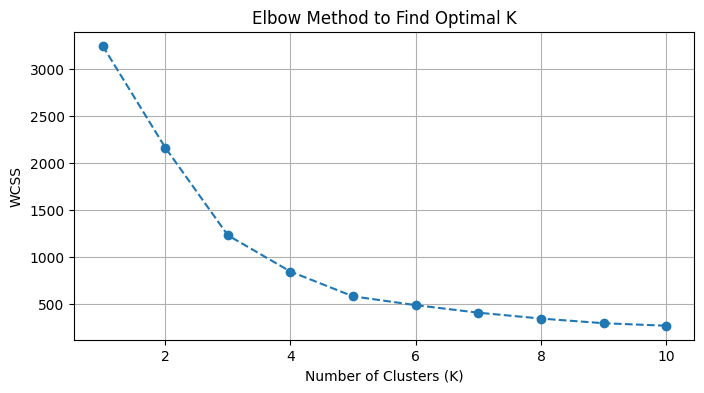

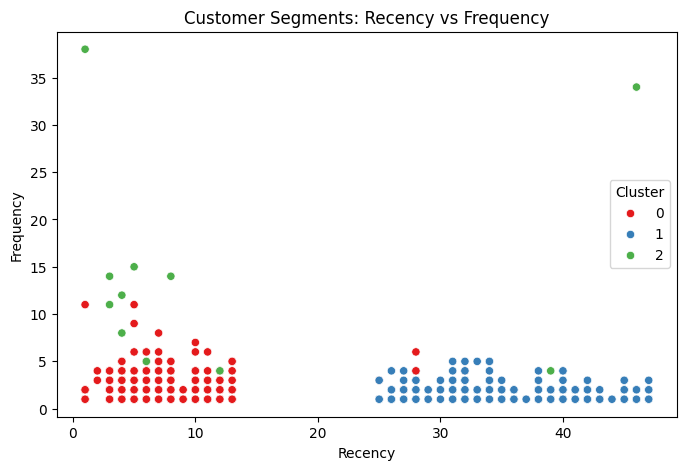

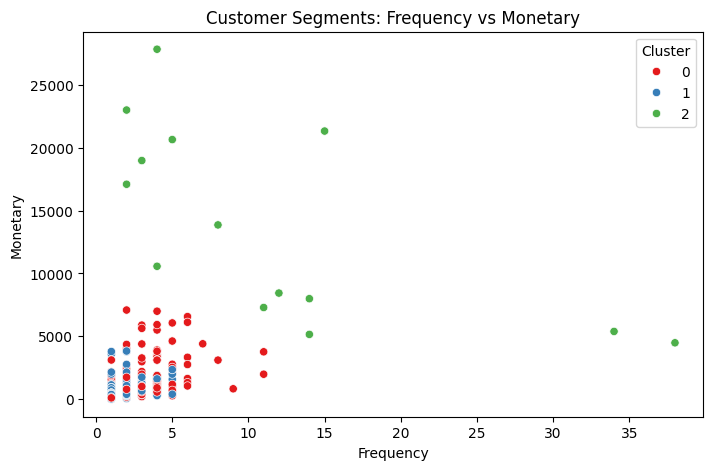

--- Cluster Profile Mean Values ---
           Recency  Frequency      Monetary
Cluster                                    
0         7.560526   2.076316    940.467711
1        37.505095   1.311499    424.584017
2        10.214286  11.857143  13720.860714


/tmp/ipykernel_1802/1447527432.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='pastel')


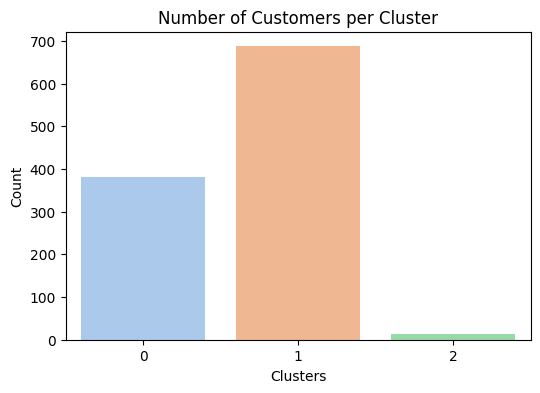

In [6]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load data
df = pd.read_csv('online_retail.csv', encoding='unicode_escape')

# 2. Inspect structure
print("Dataset Shape:", df.shape)
print("\nMissing Values Before Cleaning:\n", df.isnull().sum())

# 3. Clean Data (Drop missing CustomerIDs, remove negative quantities/prices)
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['CustomerID'] = df['CustomerID'].astype(int)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

# Create Total Purchase Value column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Define reference date as max date in dataset + 1 day
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate data by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
})

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalAmount': 'Monetary'}, inplace=True)
print("--- Descriptive Statistics of RFM Data ---")
print(rfm.describe())

# Use StandardScaler to bring columns to same scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Convert back to DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
print("Standardized Data Preview:")
print(rfm_scaled_df.head())

# Calculate WCSS for K values from 1 to 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Choose optimal K based on Elbow plot (e.g., K = 3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# Visualisation 1: Recency vs Frequency
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title('Customer Segments: Recency vs Frequency')
plt.show()

# Visualisation 2: Frequency vs Monetary
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Customer Segments: Frequency vs Monetary')
plt.show()

# 1. Calculate Mean Values per cluster
cluster_profile = rfm.groupby('Cluster').mean()
print("--- Cluster Profile Mean Values ---")
print(cluster_profile)

# 2. Bar Chart: Number of customers per cluster
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm, x='Cluster', palette='pastel')
plt.title('Number of Customers per Cluster')
plt.xlabel('Clusters')
plt.ylabel('Count')
plt.show()




### Actionable Business Recommendations Based on Customer Clusters

1. **Cluster 0 (Best Customers / Champions):**
   * **Profile:** Low Recency (shopped recently), High Frequency, High Monetary.
   * **Marketing Action:** Reward them with loyalty programs, early access to new product launches, and personalized premium offers. Avoid heavy discounting.

2. **Cluster 1 (At-Risk / Churning Customers):**
   * **Profile:** High Recency (haven't shopped in a long time), Low Frequency, Low Monetary.
   * **Marketing Action:** Launch "Win-back" email campaigns with aggressive discount coupons. Conduct feedback surveys to find out why they stopped buying.

3. **Cluster 2 (New / Potential Loyalists):**
   * **Profile:** Moderate/Low Recency, Moderate Frequency, Moderate Monetary.
   * **Marketing Action:** Send product recommendation emails based on their initial purchases. Offer milestone rewards (e.g., "Get 15% off on your 3rd order") to increase frequency.
